In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

# 1. Cargar el dataset AirQualityUCI.csv
# Este dataset europeo usa ';' como separador y ',' para los decimales
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# 2. Limpieza básica (el CSV suele tener filas y columnas extra vacías al final)
df = df.dropna(how='all', axis=1) # Elimina columnas completamente vacías
df = df.dropna(how='all', axis=0) # Elimina filas completamente vacías

# 3. Filtrar valores nulos (-200) de la columna de Temperatura ('T')
# Justo lo que explicaste en la pregunta 1 de la teoría
df_filtrado = df[df['T'] != -200].copy()

# 4. Extraer los datos de temperatura y darles forma de columna (N, 1)
datos = df_filtrado['T'].values.reshape(-1, 1)

# 5. Escalar los datos entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
serie_escalada = scaler.fit_transform(datos)

print(f"Dataset AirQualityUCI cargado y limpiado correctamente.")
print(f"Forma de la serie original: {df.shape}")
print(f"Forma de la serie tras quitar los -200: {serie_escalada.shape}")

Dataset AirQualityUCI cargado y limpiado correctamente.
Forma de la serie original: (9357, 15)
Forma de la serie tras quitar los -200: (8991, 1)


In [4]:
def crear_ventanas(dataset, window_size=24):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:(i + window_size), 0])
        y.append(dataset[i + window_size, 0])
    return np.array(X), np.array(y)

# Definimos mirar las últimas 24 horas (un ciclo diario completo)
window_size = 24 

# Construcción de las secuencias estructuradas
X, y = crear_ventanas(serie_escalada, window_size)

# Redimensionar el tensor de entrada a formato 3D: [Muestras, Pasos de tiempo, Características]
X = X.reshape((X.shape[0], X.shape[1], 1))

# División cronológica de los conjuntos (80% entrenamiento, 20% prueba)
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("--- Celda 2 Completada ---")
print(f"Dimensiones del conjunto de entrenamiento X_train: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba X_test: {X_test.shape}")

--- Celda 2 Completada ---
Dimensiones del conjunto de entrenamiento X_train: (7173, 24, 1)
Dimensiones del conjunto de prueba X_test: (1794, 24, 1)


In [5]:
# Función para construir, compilar, entrenar y evaluar cada tipo de red
def entrenar_y_evaluar(tipo='LSTM'):
    model = Sequential()
    
    if tipo == 'SimpleRNN':
        model.add(SimpleRNN(50, input_shape=(window_size, 1)))
    elif tipo == 'LSTM':
        model.add(LSTM(50, input_shape=(window_size, 1)))
    elif tipo == 'GRU':
        model.add(GRU(50, input_shape=(window_size, 1)))
        
    model.add(Dense(1))

    # Optimizamos con MSE (Mean Squared Error) y medimos con MAE (Mean Absolute Error)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    print(f"\n================ Entrenando {tipo} ================")
    # Guardamos todo el registro del entrenamiento en la variable history
    history = model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=1)

    # Evaluación objetiva con el conjunto de test aislado
    mse, mae = model.evaluate(X_test, y_test, verbose=0)
    
    return model, mae, history

# Ejecución secuencial del entrenamiento para los tres modelos
m_simple, mae_simple, hist_simple = entrenar_y_evaluar('SimpleRNN')
m_lstm, mae_lstm, hist_lstm = entrenar_y_evaluar('LSTM')
m_gru, mae_gru, hist_gru = entrenar_y_evaluar('GRU')

print("\n--- Celda 3 Completada ---")
print("RESULTADOS FINALES DISPONIBLES (MAE Normalizado):")
print(f"SimpleRNN: {mae_simple:.4f} | LSTM: {mae_lstm:.4f} | GRU: {mae_gru:.4f}")


================ Entrenando SimpleRNN ================
Epoch 1/5


c:\Users\tteru\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0167 - mae: 0.0749
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - mae: 0.0307
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013 - mae: 0.0268
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - mae: 0.0260
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 - mae: 0.0237

================ Entrenando LSTM ================
Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0121 - mae: 0.0819
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054 - mae: 0.0593
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021 - mae: 0.0348
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0017 - mae: 0.0315
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - mae: 0.0307

================ Entrenando GRU ================
Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0165 - mae: 0.0858
Epoch 2/5
113/113 ━━━━━━━━━━━

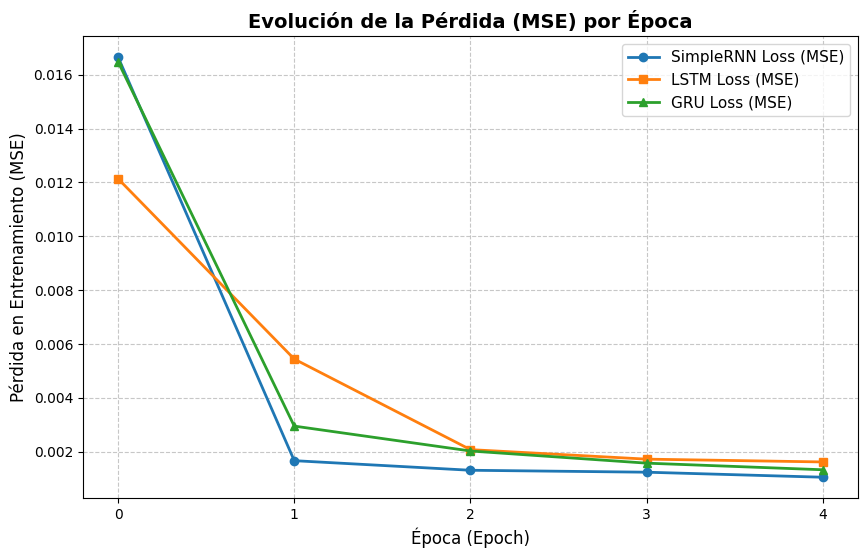

--- Celda 4 Completada. Gráfica generada con éxito. ---


In [6]:
# Creación del lienzo para comparar las curvas de aprendizaje
plt.figure(figsize=(10, 6))

# Trazado de las curvas de error (Loss) recolectadas de los historiales
plt.plot(hist_simple.history['loss'], label='SimpleRNN Loss (MSE)', marker='o', linewidth=2)
plt.plot(hist_lstm.history['loss'], label='LSTM Loss (MSE)', marker='s', linewidth=2)
plt.plot(hist_gru.history['loss'], label='GRU Loss (MSE)', marker='^', linewidth=2)

# Configuración estructural y estética del gráfico
plt.title('Evolución de la Pérdida (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época (Epoch)', fontsize=12)
plt.ylabel('Pérdida en Entrenamiento (MSE)', fontsize=12)
plt.xticks(range(5)) # Forzamos etiquetas limpias para las 5 épocas (0 a 4)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Renderizar el gráfico final en pantalla
plt.show()
print("--- Celda 4 Completada. Gráfica generada con éxito. ---")